In [1]:
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.metrics import (
    silhouette_score, 
    r2_score,
)

import xgboost as xgb
from umap import UMAP
import shap

# =========================
# Custom utilities
# =========================
import utils.cross_validation as cval
import utils.umap_utils as uutil
import utils.exp_utils as exp

# =========================
# Optional helpers (math functions already included above)
# =========================
from math import radians, sin, cos, sqrt, asin
import math


def select_one_point_remove_buffer(df, 
                                   buffer_km=50, 
                                   lat_col='lat', lon_col='lon', 
                                   random_seed=None):
    """
    Select exactly ONE point and remove ALL other points within buffer_km.
    
    Parameters:
    - df: DataFrame with coordinates
    - buffer_km: radius in km to remove points (default: 50)
    - lat_col: latitude column name
    - lon_col: longitude column name
    - random_seed: random seed for reproducibility
    - method: 'random' or 'first' or index
    
    Returns:
    - selected_df: DataFrame with 1 selected point
    - remaining_df: DataFrame with points > buffer_km away (kept)
    - removed_df: DataFrame with points <= buffer_km away (removed)
    """
    
    if random_seed is not None:
        np.random.seed(random_seed)
    

    selected_idx = np.random.choice(df.index, 1, replace=False)[0]
 
    # Get selected point coordinates
    selected_point = df.loc[selected_idx]
    lat_sel = selected_point[lat_col]
    lon_sel = selected_point[lon_col]
    
    # Classify all points
    selected_points = [selected_idx]
    removed_points = []
    remaining_points = []
    
    for idx in df.index:
        if idx == selected_idx:
            continue
        
        # Calculate distance to selected point
        dist = haversine(lat_sel, lon_sel, 
                        df.loc[idx, lat_col], 
                        df.loc[idx, lon_col])
        
        if dist <= buffer_km:
            removed_points.append(idx)  # Too close → remove
        else:
            remaining_points.append(idx)  # Far enough → keep
    
    # Create DataFrames
    selected_df = df.loc[selected_points].copy()
    removed_df = df.loc[removed_points].copy()
    remaining_df = df.loc[remaining_points].copy()
    
    print(f"✓ Removed {len(removed_df)} points within {buffer_km}km")
    
    return selected_df, remaining_df, removed_df


def train_test_split_v3(df, random_key, n_points_to_select=2, buffer_km=100):

    # selected, remaining, removed = select_points_stratified(sub_df, 
    #     n_per_biome=n_points_to_select,
    #     buffer_km=buffer_km,
    #     lat_col='lat',
    #     lon_col='lon',
    #     random_seed=random_key
    # )
    selected, remaining, removed = select_one_point_remove_buffer(df, 
                                   buffer_km=50, 
                                   lat_col='lat', lon_col='lon', 
                                   random_seed=random_key)
    

    test = selected.drop(columns=['lat', 'lon', 'biome'])
    test_biomes=selected[['biome']]
    train= remaining.drop(columns=['lat', 'lon', 'biome'])

    y=['transformed npp'] 
    X_train=train.drop(columns=y+['PID'])

    y_train = train['transformed npp'].values

    X_test= test.drop(columns=y+['PID' ])
    y_test = test['transformed npp'].values
    
    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test, test_biomes, scaler


def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in km"""
    R = 6371  # Earth's radius in km
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    return R * c


/home/qli/Projects/env1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Essential Params and Dicts

color_map = {
    'Species Richness': 'grey',
    'Shannon Diversity': "#8040a0",
    "Raos_Q": 'darkolivegreen',
    "Simpson's Index":  "#cca9dd",
    'Functional_Evenness': "#94BC92"
}
biome_colors = {
    'Temperate broadleaf forests': "#4881BE",   # Sea Green (mid-tone green)
    'Temperate conifer forests':   "#016742",   # Very Dark Green (near-black green)
    'Temperate grasslands':        '#DAA520',   # Goldenrod (yellow-brown)
    'Xeric shrublands':             '#B5651D',   # Burnt Orange-Brown (desert)
    'Boreal and Tundra forests':    '#4169E1',   # Royal Blue (cool, distinct from green)
    'Mediterranean woodlands':      '#9ACD32',   # Yellow-Green (olive, warm-leaning)
    'Tropical':                     '#FF00FF',   # Magenta (maximally distinct, non-natural but unmistakable)
    'NaN':                          '#D3D3D3'    # Light Gray
}

with open("config/ex_config.yaml", "r") as f:
    config = yaml.safe_load(f)

biome_mapping = config["biome_mapping"]
random_key=config["random_key"]

biome_list=["Temperate broadleaf forests", "Temperate conifer forests", "Temperate grasslands",
            "Xeric shrublands", "Boreal and Tundra forests", "Tropical",
            "Mediterranean woodlands"]

In [3]:
fd_df = pd.read_csv('data/final/final_dataset.csv')
PID_df= pd.read_csv('data/lookup/PID_location_all.csv')

fd_df=fd_df.merge(PID_df[['PID','lat','lon', 'biome']], on='PID', how='left')

fd_df.dropna(subset=['transformed npp', 'pet_std' , 'Raos_Q', 'Functional_Evenness', 'Soil Moisture',
                    'Species Richness', 'Shannon Diversity', "Simpson's Index", 'Functional_Richness'], inplace=True)
fd_df = fd_df[fd_df["treecover2000"] > 60]

fd_df.drop_duplicates(subset=['PID'], inplace=True)

ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]
#Preprocessing the data for Random forest regression

fd_df['biome'] = fd_df['biome'].map(biome_mapping) # Only run this once ! 

biome_dfs = {k: v for k, v in fd_df.groupby('biome')}

fd_df = fd_df[fd_df["WSCI"] != 0]


In [4]:
fd_df["WSCI_group"] = pd.qcut(fd_df["WSCI"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])

df_q1 = fd_df[fd_df["WSCI_group"] == "Q1"]
df_q2 = fd_df[fd_df["WSCI_group"] == "Q2"]
df_q3 = fd_df[fd_df["WSCI_group"] == "Q3"]
df_q4 = fd_df[fd_df["WSCI_group"] == "Q4"]
df_q5 = fd_df[fd_df["WSCI_group"] == "Q5"]

dfs = [df_q1, df_q2, df_q3, df_q4, df_q5]


In [5]:
def plot_shap_with_polynomial_stats_v3(shap_values, X, features, degree=2, name=None,
                                       ):
    
    """
    Plot SHAP dependence with polynomial trend and statistics.
    Single feature list, one plot per feature, no overlapping axes.
    Line colour is taken from biome_color dict if provided and biome is specified.
    """
    default_colors = {
        'scatter': "#999CC2",
        'line':    "#3E47C6",
    }

    line_color    = default_colors['line']
    scatter_color = default_colors['scatter']

    n_plots = len(features)
    n_cols = 3
    n_rows = math.ceil(n_plots / n_cols)
    n_samples = min(shap_values.shape[0], 2000)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    axes_flat = np.array(axes).flatten()
    fig.subplots_adjust(hspace=0.5, wspace=0.4)
    slopes=[]
    zeros=[]
    for i, (ax, var) in enumerate(zip(axes_flat, features)):

        feature_values = X[var].values.astype(np.float64)
        feature_idx = list(X.columns).index(var)
        shap_feature = shap_values[:, feature_idx].astype(np.float64)

        # Skip if all zeros
        if np.all(feature_values == 0):
            ax.set_visible(False)
            slopes.append(np.nan)
            zeros.append(np.nan)
            continue

        # Sample
        indices = np.random.choice(len(feature_values), n_samples, replace=False)
        fv_sample = feature_values[indices]
        sv_sample = shap_feature[indices]

        # Polynomial fit on full data
        coeffs = np.polyfit(feature_values, shap_feature, degree)
        poly_func = np.poly1d(coeffs)
        poly_deriv = np.polyder(poly_func)
        midpoint = np.median(feature_values)
        slopes.append(poly_deriv(midpoint))

        # Zero crossing — find where polynomial crosses y=0
        x_smooth = np.linspace(feature_values.min(), feature_values.max(), 20000)
        y_smooth = poly_func(x_smooth)
        zeros.append((np.where(np.diff(np.sign(y_smooth)))[0]))  
        # R²
        y_pred = poly_func(feature_values)
        ss_res = np.sum((shap_feature - y_pred) ** 2)
        ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
        r2 = 1 - (ss_res / ss_tot)

        # Scatter
        ax.scatter(fv_sample, sv_sample,
                   alpha=0.2, s=20, c=scatter_color,
                   linewidth=0.3, zorder=1)

        # Trend line
        x_smooth = np.linspace(feature_values.min(), feature_values.max(), 200)
        y_smooth = poly_func(x_smooth)
        # ax.plot(x_smooth, y_smooth,
        #         c=line_color, linewidth=2,
        #         label=f'Degree {degree} poly | R²={r2:.3f}',
        #         zorder=10)
        # Reference line
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.8)

        ax.set_xlabel(var, fontsize=10)
        ax.set_ylabel('SHAP value', fontsize=10)
        ax.set_title(f'{var}', fontsize=11, pad=8)
        ax.legend(fontsize=8, loc='best')

        y_min = np.min(y_smooth)
        y_max = np.max(y_smooth)
        padding = 0.1 * (y_max - y_min)
        ax.set_ylim(y_min - padding, y_max + padding)

    # Hide unused axes
    for ax in axes_flat[n_plots:]:
        ax.set_visible(False)

    title = 'SHAP Dependence'
    fig.suptitle(title, fontsize=13, y=1.02)

    if name:
        plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.show()
    return slopes, zeros


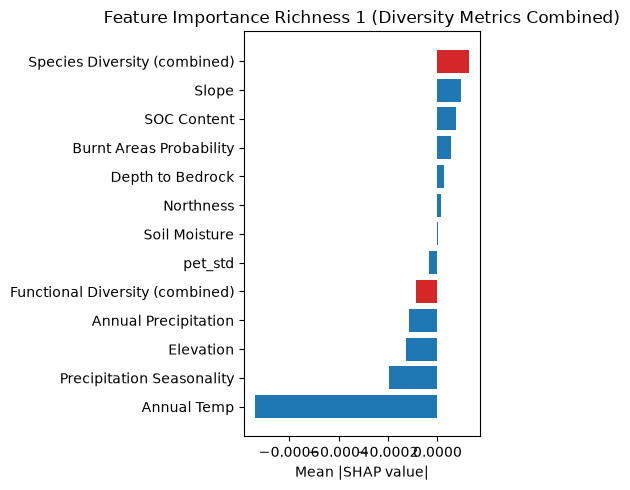

/tmp/ipykernel_1333496/510889963.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='best')


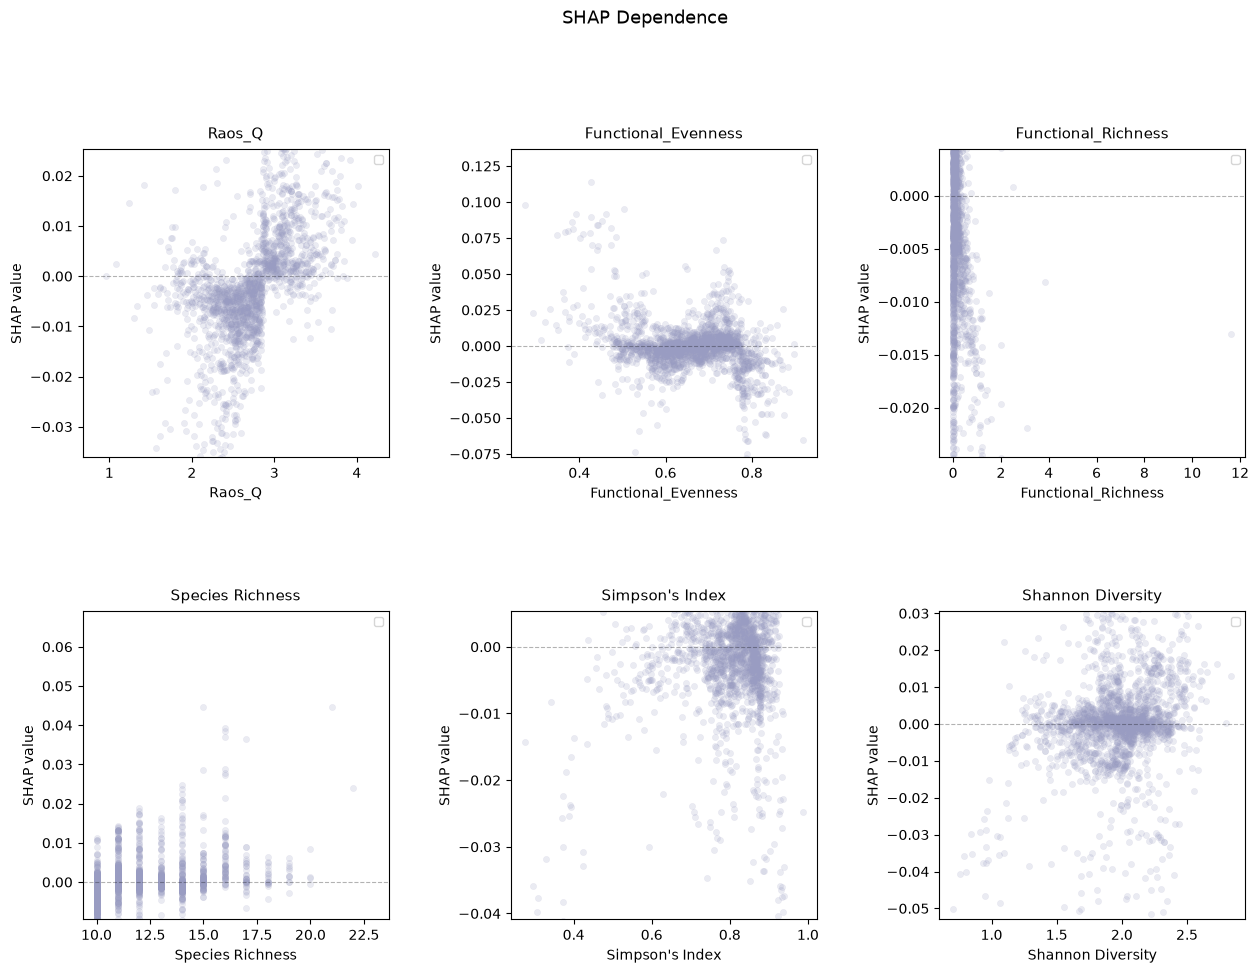

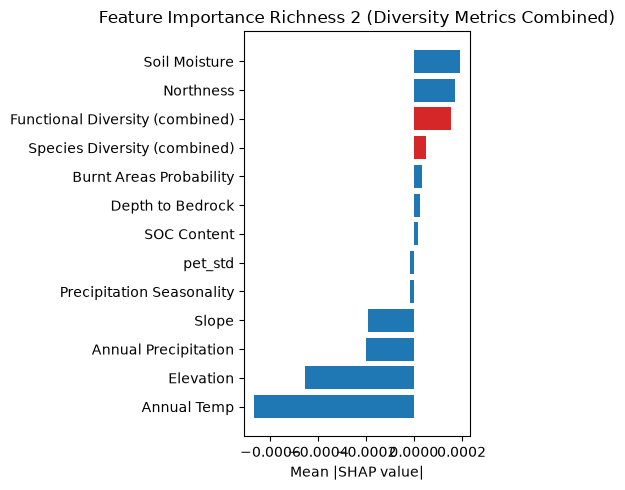

/tmp/ipykernel_1333496/510889963.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='best')


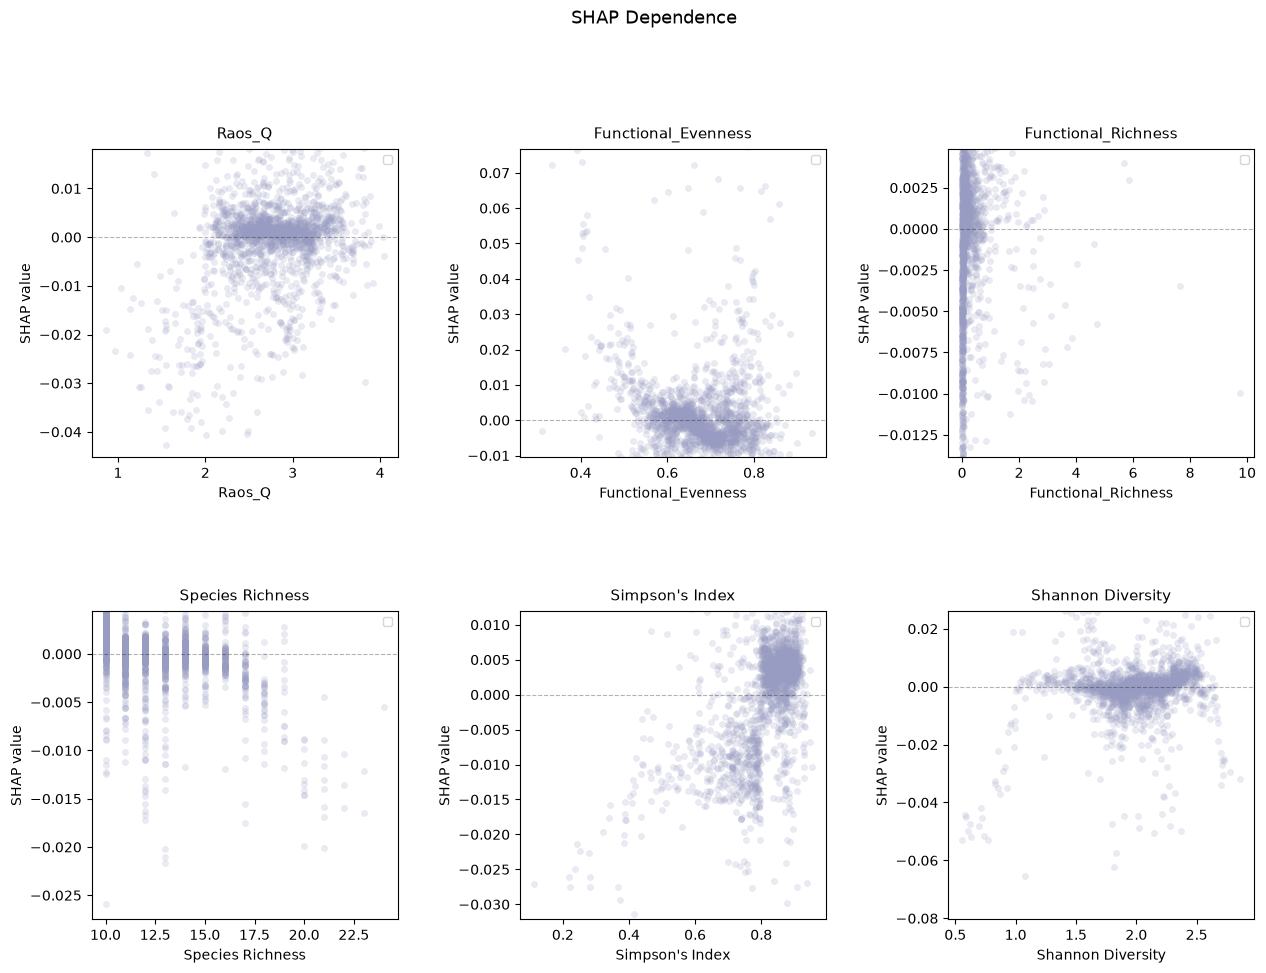

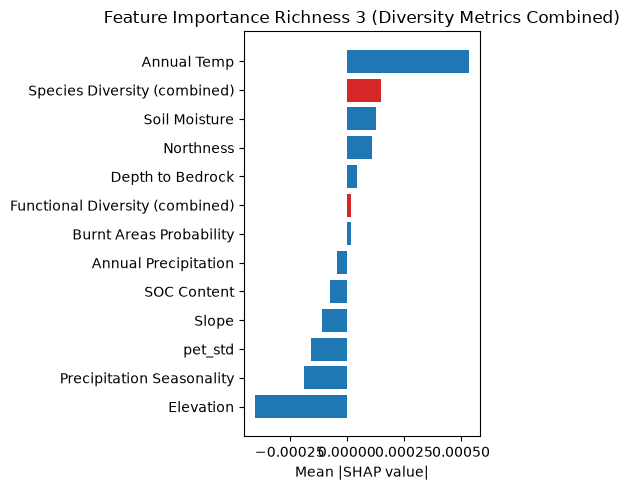

/tmp/ipykernel_1333496/510889963.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='best')


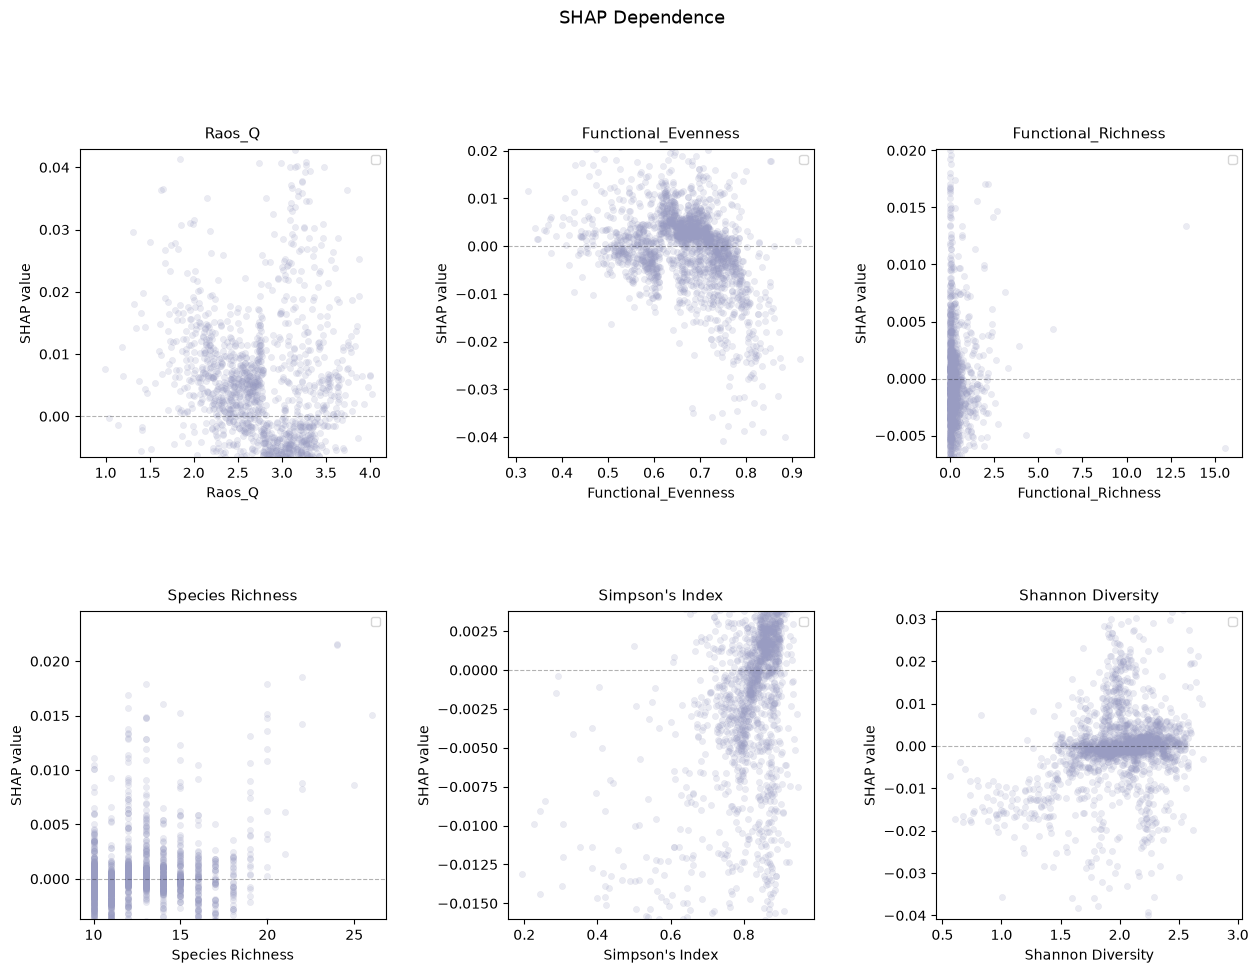

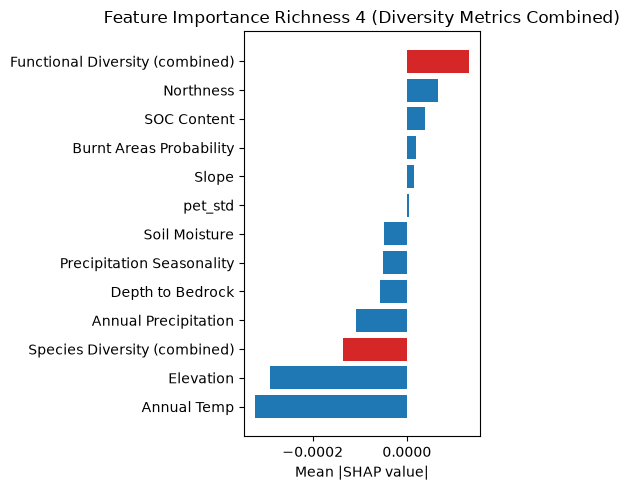

/tmp/ipykernel_1333496/510889963.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='best')


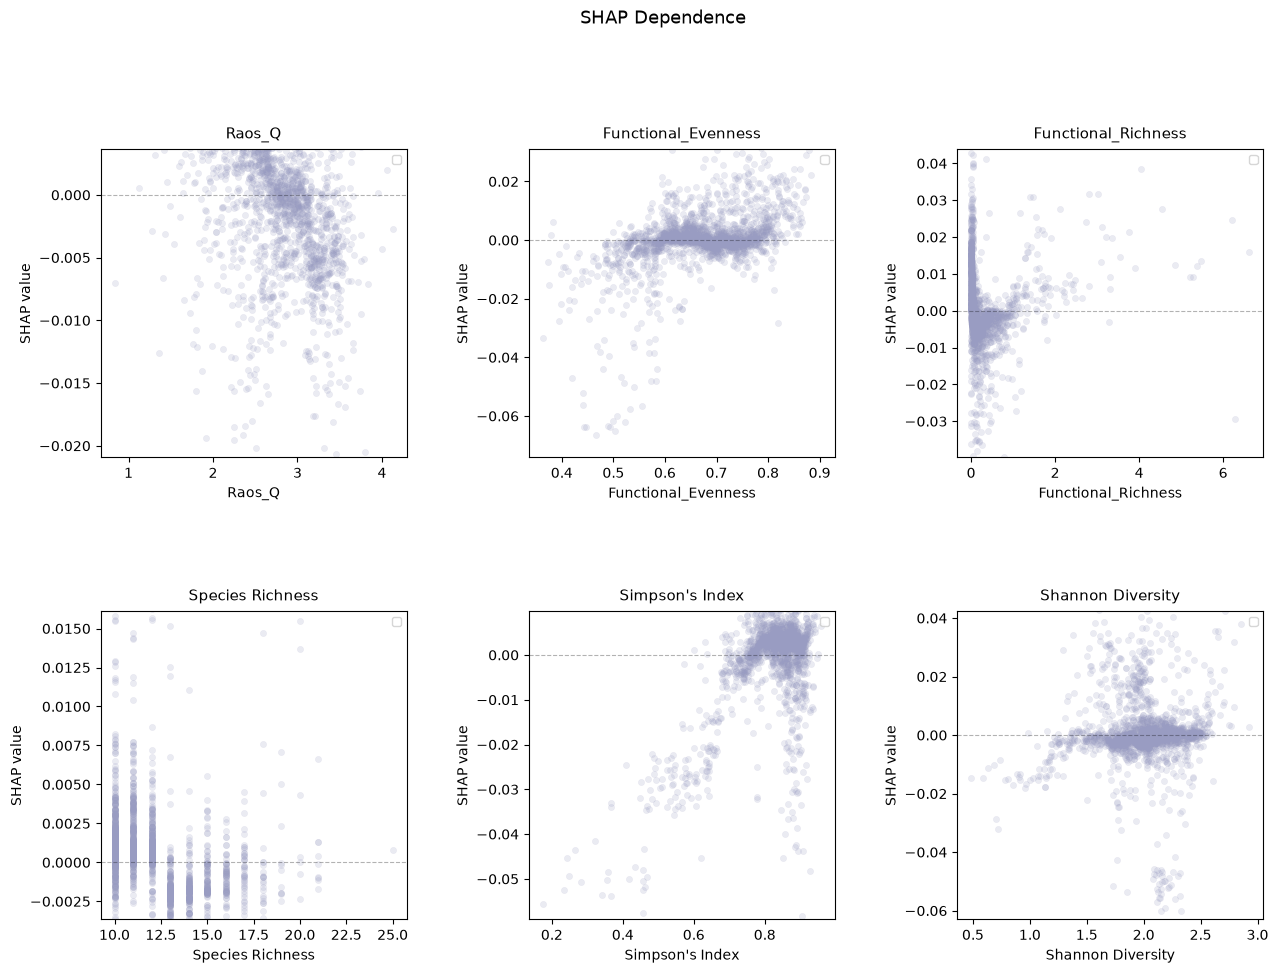

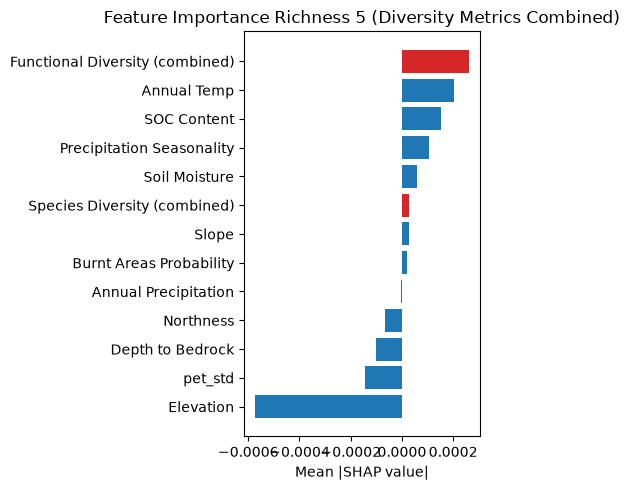

/tmp/ipykernel_1333496/510889963.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='best')


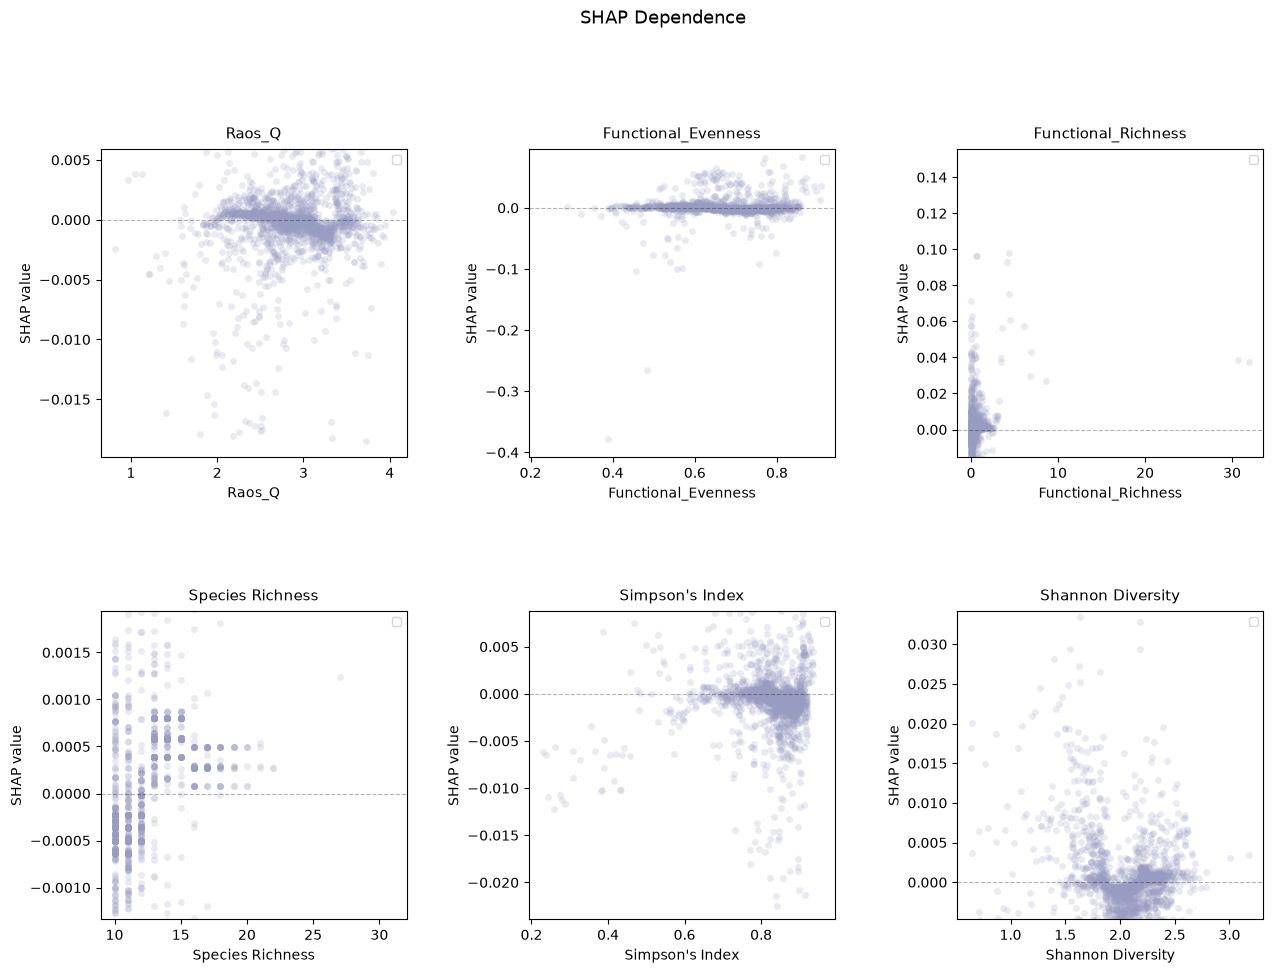

In [6]:
shap_df=pd.DataFrame(columns=['group', 'feature', 'mean_abs_shap'])
shap_df2=pd.DataFrame()
slopes_df=pd.DataFrame(columns=['group', 'feature', 'slope', 'zero_points'])
pdp_curves = {}  

for i, df in enumerate(dfs, start=1):
    X=df.drop(columns=[ 'transformed npp', 'PID', 'lat', 'lon', 'biome', 'treecover2000', 'WSCI', 'WSCI_group','aridity_delta'])
    X.columns
    y=df['transformed npp'].values
    scaler= StandardScaler()
    scaler.fit_transform(X)
    X = pd.DataFrame(
        X,
        columns=scaler.feature_names_in_
    )

    model = xgb.XGBRegressor(**config["global"])
    model.fit(X, y )

    explainer = shap.Explainer(model, approximate=True)

    shap_vals = explainer.shap_values(X, approximate=True)
    mean_shap = shap_vals.mean(axis=0)
    model_features = getattr(model, "feature_names_in_", X.columns)
    shap_values = explainer(X, approximate=True )

    shap_importance = pd.DataFrame({
    "WSCI": i,
    "feature": model_features,
    "mean_abs_shap": mean_shap
    }).sort_values("mean_abs_shap", ascending=False)

    all_shap_df = pd.DataFrame(
        shap_vals,
        columns=[f'shap_{col}' for col in X.columns],
        index=X.index
    )
    results = pd.concat(
        [
            df.loc[df.index, ["PID", "lat", "lon"]].reset_index(drop=True),
            all_shap_df.reset_index(drop=True)
        ],
        axis=1
    )
    shap_df2 = pd.concat([shap_df2,results], ignore_index=False)

    shap_df = pd.concat([shap_df, shap_importance], ignore_index=True)

    diversity_vars = ['Raos_Q', 'Functional_Evenness', "Functional_Richness", 'Species Richness', "Simpson's Index", 'Shannon Diversity']

    diversity_vars_f = ['Raos_Q', 'Functional_Evenness', 'Functional_Richness']
    diversity_vars_s = ["Simpson's Index", 'Shannon Diversity', 'Species Richness']

    # Sum SHAP importance within each group
    functional_sum = shap_importance.loc[
        shap_importance['feature'].isin(diversity_vars_f), 'mean_abs_shap'
    ].sum()

    species_sum = shap_importance.loc[
        shap_importance['feature'].isin(diversity_vars_s), 'mean_abs_shap'
    ].sum()

    # Remove all individual diversity variables (union of both lists) from the table
    all_diversity_vars = set(diversity_vars_f) | set(diversity_vars_s)
    shap_importance_combined = shap_importance[
        ~shap_importance['feature'].isin(all_diversity_vars)
    ].copy()

    # Add the two combined rows
    summary_rows = pd.DataFrame({
        'feature': ['Functional Diversity (combined)', 'Species Diversity (combined)'],
        'mean_abs_shap': [functional_sum, species_sum]
    })

    shap_importance_combined = pd.concat(
        [shap_importance_combined, summary_rows], ignore_index=True
    ).sort_values('mean_abs_shap', ascending=False)

    # Plot
    fig, ax = plt.subplots(figsize=(5,5))
    colors = ['#d62728' if f in summary_rows['feature'].values else '#1f77b4'
            for f in shap_importance_combined['feature']]

    bars = ax.barh(
        shap_importance_combined['feature'],
        shap_importance_combined['mean_abs_shap'],
        color=colors
    )
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'Feature Importance Richness {i} (Diversity Metrics Combined)')

    plt.tight_layout()
    plt.show()

    slopes, zeros = plot_shap_with_polynomial_stats_v3(shap_vals, X, diversity_vars, degree=3, name=None)

    # Splines to fit line or binning  

    slopes_df = pd.concat([slopes_df, pd.DataFrame({
        'group': i,
        'feature': diversity_vars,
        'slope': slopes,
        'zero_points': zeros
    })], ignore_index=True)


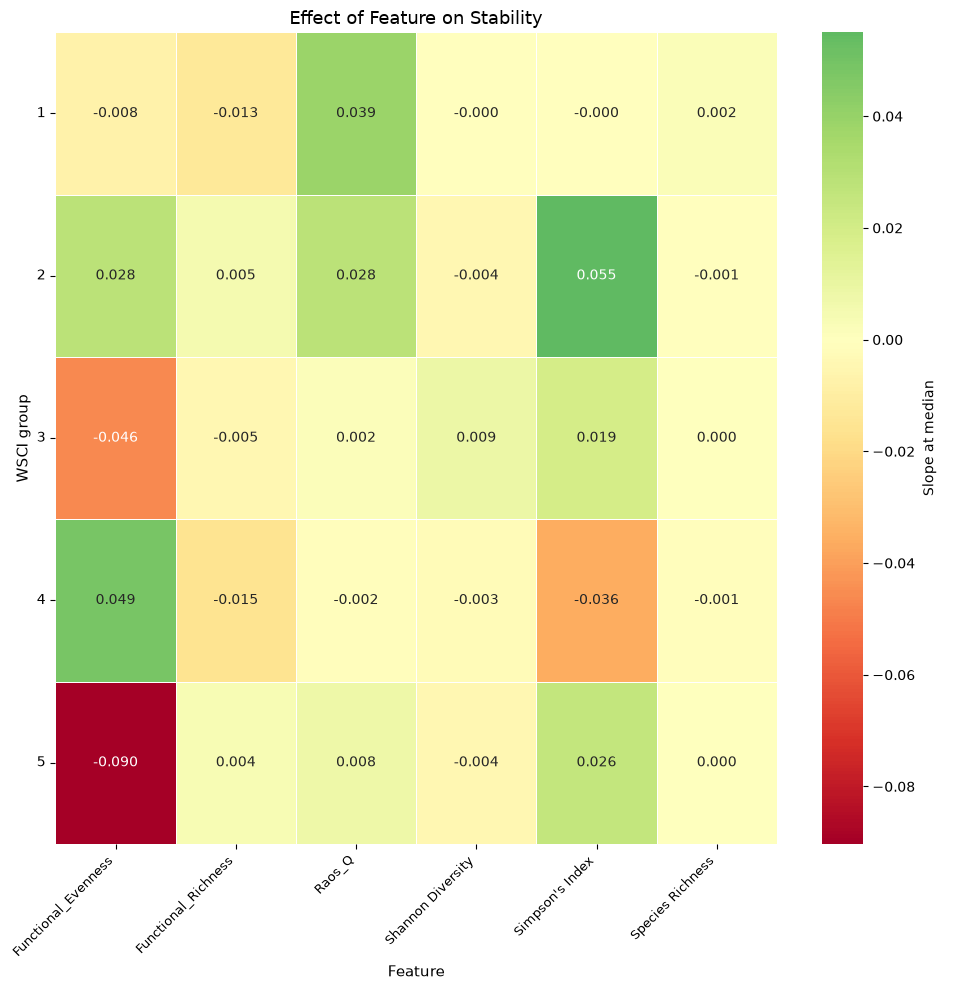

In [7]:
slopes_df['slope'] = pd.to_numeric(slopes_df['slope'], errors='coerce')

slope_pivot = slopes_df.pivot(index='group', columns='feature', values='slope')

fig, ax = plt.subplots(figsize=(10,10))

sns.heatmap(
    slope_pivot,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Slope at median\n'}
)

ax.set_title('Effect of Feature on Stability', fontsize=13)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('WSCI group', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()